# Classic games

1. State of the Art
2. Game Theory
3. Minimax Search
4. Self-Play Reinforcement Learning
5. Combining Reinforcement Learning and Minimax Search
6. Reinforcement Learning in Imperfect-Information Games
7. Conclusions

## Why Study Classic Games?

- Simple rules, deep concepts
- Studied for hundreds or thousands of years
- Meaningful IQ test
- *Drosophila* of artificial intelligence
- Microcosms encapsulating real world issues
- Games are fun!

## AI in Games: State of the Art

| Program | Level of Play | Program to Achieve Level |
|---|---|---|
| Checkers | Perfect | *Chinook* |
| Chess | Superhuman | *Deep Blue* |
| Othello | Superhuman | *Logistello* |
| Backgammon | Superhuman | *TD-Gammon* |
| Scrabble | Superhuman | *Maven* |
| Go | Grandmaster | *MoGo*¹, *Crazy Stone*², *Zen*³ |
| Poker⁴ | Superhuman | *Polaris* |

¹ 9×9 board · 
² 9×9 and 19×19 · 
³ 19×19 · 
⁴ Heads-up Limit Texas Hold'em
>
> "Perfect" means the game is solved — the program plays the provably optimal strategy. Against any opponent, the perfect player will never lose. Best possible outcome is a win or draw depending on the game's nature. For Checkers specifically, it's a draw under perfect play from both sides

> "Superhuman" means it beats the best humans. 

> "Grandmaster" (Go) means it reached the top human rank, but full superhuman came later (AlphaGo, not listed here).

> "Perfect" > "superhuman" > "grandmaster"

---

## RL in Games: State of the Art (2018)

| Program | Level of Play | RL Program to Achieve Level |
|---|---|---|
| Checkers | Perfect | *Chinook* |
| Chess | International Master | *KnightCap / Meep* |
| Othello | Superhuman | *Logistello* |
| Backgammon | Superhuman | *TD-Gammon* |
| Scrabble | Superhuman | *Maven* |
| Go | Grandmaster | *MoGo*¹, *Crazy Stone*², *Zen*³ |
| Poker⁴ | Superhuman | *SmooCT* |

¹ 9×9 · ² 9×9 and 19×19 · ³ 19×19 · ⁴ Heads-up Limit Texas Hold'em


> This slide contrasts with the previous one by asking: how much of that performance was achieved specifically by RL methods? 

> The key difference is Chess — the best RL-only programs (KnightCap, Meep) only reached International Master, whereas Deep Blue (mostly search + handcrafted eval) reached Superhuman. 

> This highlights that RL alone was not always sufficient; hybrid approaches or pure search dominated some games before deep RL (AlphaZero) changed the picture.

## Game theory

### Optimality in Games

- In games, you've opponents. It's no longer the agent against the environment, but agent against agents/human
- What is the optimal policy $\pi^i$ for the $i$-th player?
- If all other players fix their policies $\pi^{-i}$
- **Best response** $\pi^i_*(\pi^{-i})$ is the optimal policy against those fixed policies
- **Nash equilibrium** is a joint policy for all players:

$$\pi^i = \pi^i_*(\pi^{-i})$$

- such that every player's policy is a best response
- i.e. no player would choose to deviate from Nash

> The notation $\pi^{-i}$ means "the policies of all players *except* player $i$".
>
> **Best response** answers: *given that everyone else plays fixed strategies, what is my optimal policy?* It is a function of the opponents' strategies.
>
> **Nash equilibrium** is a fixed point: every player is simultaneously playing their best response to everyone else. No single player can improve their outcome by unilaterally changing strategy — so the joint policy is stable.
>
> Note that Nash equilibrium does not require coordination or communication; it is a self-consistent solution where no deviation is profitable.

### Single-Agent and Self-Play Reinforcement Learning

- **Best response** is the solution to a single-agent RL problem
  - Other players become part of the environment
  - Game is reduced to an MDP
  - Best response is the optimal policy for this MDP

- **Nash equilibrium** is the fixed point of self-play RL
  - Experience is generated by playing games between agents:

    $$a_1 \sim \pi^1,\ a_2 \sim \pi^2,\ \ldots$$

  - Each agent learns best response to other players
  - One player's policy determines another player's environment
  - All players are adapting to each other

> **Best response as single-agent RL:** if you treat all other players as fixed parts of the environment, the multi-player game collapses into a standard MDP. Solving that MDP (e.g. with Q-learning, policy gradient) gives your best response. This is valid only if the other players' policies are truly fixed.
>
> **Self-play:** instead of fixing opponents, all agents learn simultaneously. Each agent samples actions from its current policy ($a_i \sim \pi^i$) and updates based on the outcomes. Because every agent is changing, each agent's environment is non-stationary — the MDP assumption is technically violated. However, if the process converges, the fixed point is exactly a Nash equilibrium: every agent is a best response to all others simultaneously.
>
> This is the core idea behind programs like TD-Gammon, AlphaGo, and OpenAI Five — they trained by playing against themselves rather than against a fixed opponent.

### Single-Agent and Self-Play Reinforcement Learning

- **Best response is solution to single-agent RL problem**
  - Other players become part of the environment
  - Game is reduced to an MDP
  - Best response is optimal policy for this MDP
  - *When you fix all other players' strategies, your decision problem collapses into a standard MDP — the other agents are just part of the transition dynamics, and solving it gives you the best response.*

- **Nash equilibrium is fixed-point of self-play RL**
  - Experience is generated by playing games between agents:
    $a_1 \sim \pi^1,\ a_2 \sim \pi^2,\ \ldots$
  - Each agent learns best response to other players
  - One player's policy determines another player's environment
  - All players are adapting to each other
  - **This is the multi-agent twist: nobody's environment is stationary anymore**. Each agent is simultaneously solving its own MDP, but the MDP keeps shifting as the other agents update their policies. 
  - A Nash equilibrium is reached **when every agent is already playing a best response — no one has incentive to deviate, so the system is at a fixed point**.

### Two-Player Zero-Sum Games

We will focus on a special class of games:

- **A two-player game has two (alternating) players**
  - We will name player 1 *white* and player 2 *black*
  - *Players take turns — this covers board games like Chess or Go, where white moves, then black, then white, etc.*

- **A zero-sum game has equal and opposite rewards for black and white:**
  $$R^1 + R^2 = 0$$
  - *Whatever white wins, black loses by exactly the same amount, and vice versa. There is no cooperation possible — the interests are perfectly opposed. If white gets +1 (win), black gets -1 (loss).*

We consider methods for finding Nash equilibria in these games:

- **Game tree search** (i.e. planning)
  - *Explicitly look ahead in the game tree — minimax search, alpha-beta pruning, MCTS. No learning from experience; you use a model of the game to plan.*

- **Self-play reinforcement learning**
  - *Learn by playing against yourself. No hand-crafted model needed — the agent improves by generating its own experience, progressively finding stronger best responses.*

### Perfect and Imperfect Information Games

- **A perfect information (or Markov) game is fully observed**
  - Examples: Chess, Checkers, Othello, Backgammon, Go
  - *Both players see the complete game state at all times. Nothing is hidden. This maps cleanly to an MDP: the state is fully observable, so standard planning and RL methods apply directly.*

- **An imperfect information game is partially observed**
  - Examples: Scrabble, Poker
  - *Players have private information (hidden cards, unknown tile draws). The true game state is not fully visible — each player only sees their own observation. This requires reasoning over beliefs about what the opponent might hold, making the problem significantly harder (POMDP territory).*

- **We focus first on perfect information games**
  - *The fully observed setting is the natural starting point: cleaner theory, well-studied algorithms (minimax, MCTS, AlphaGo/AlphaZero), and the Markov property holds — the current state is sufficient to act optimally.*

## Minimax

- **A value function defines the expected total reward given joint policies $\pi = \langle \pi^1, \pi^2 \rangle$:**
  $$v_\pi(s) = \mathbb{E}_\pi \left[ G_t \mid S_t = s \right]$$
  - *In a two-player game, the outcome depends on both players' policies simultaneously. The value function tells you the expected return from state $s$ when white plays $\pi^1$ and black plays $\pi^2$.*

- **A minimax value function maximizes white's expected return while minimizing black's expected return:**
  $$v_*(s) = \max_{\pi^1} \min_{\pi^2} \, v_\pi(s)$$
  - *White wants to maximize, black wants to minimize (zero-sum). The minimax value is what white can guarantee regardless of how black plays — it assumes the opponent plays optimally against you. This is the conservative, worst-case-optimal strategy.*

- **A minimax policy is a joint policy $\pi = \langle \pi^1, \pi^2 \rangle$ that achieves the minimax values**
  - *The pair of strategies that together realize $v_*(s)$ at every state.*

- **There is a unique minimax value function**
  - *Unlike general games, in two-player zero-sum games the minimax solution is unique — both players agree on the value of every state.*

- **A minimax policy is a Nash equilibrium**
  - *Neither player can improve by deviating unilaterally: white can't do better against an optimal black, and black can't do better against an optimal white. Minimax = Nash in zero-sum games.*

### Minimax Search

<img src=imgs/image-130.png />

- **Minimax values can be found by depth-first game-tree search**
  - *Starting from the current state, expand the game tree recursively. At each level, alternate between maximizing (white's turn) and minimizing (black's turn). Leaf nodes are evaluated, and values are backed up to the root. Depth-first means you go all the way to terminal states before backtracking.*

- **Introduced by Claude Shannon: *Programming a Computer for Playing Chess***
  - *The foundational 1950 paper that laid out the idea of computers playing chess by searching ahead in a game tree. The minimax principle has been central to game AI ever since.*

- **Ran on paper!**
  - *Shannon described and analyzed the algorithm entirely theoretically — there were no computers capable of running it at the time. It was a thought experiment that turned into the blueprint for decades of game-playing AI.*

### example

<img src=imgs/image-131.png /><div/>

<img src=imgs/image-132.png /><div/>

<img src=imgs/image-133.png /><div/>

<img src=imgs/image-134.png /><div/>

### Value Function in Minimax Search

- **Search tree grows exponentially**
  - *At each node you branch into all legal moves. With branching factor $b$ and depth $d$, the tree has $b^d$ nodes. For Chess ($b \approx 35$) or Go ($b \approx 250$), searching to the end of the game is computationally impossible.*

- **Impractical to search to the end of the game**
  - *Terminal states can be hundreds of moves away. Full-depth minimax is only feasible for trivial games like Tic-Tac-Toe.*

- **Instead, use a value function approximator $v(s, \mathbf{w}) \approx v_*(s)$**
  - aka *evaluation function*, *heuristic function*
  - *Rather than searching all the way to a terminal state, cut the search off at a fixed depth and evaluate the resulting position using a learned or hand-crafted function. Classic chess engines used hand-tuned features (material count, piece mobility, king safety); modern systems learn $\mathbf{w}$ from data.*

- **Use value function to estimate minimax value at leaf nodes**
  - *The approximator substitutes for the true terminal value, allowing the backed-up minimax value at the root to be computed without reaching the end of the game.*

- **Minimax search run to fixed depth with respect to leaf values**
  - *You search $d$ plies deep, evaluate all frontier nodes with $v(s, \mathbf{w})$, then back up minimax values normally. Deeper search = better estimates, at exponential cost.*

### Binary-Linear Value Function

- **Binary feature vector $\mathbf{x}(s)$**: e.g. one feature per piece
  - *Each entry is 1 if that piece is present on the board, 0 otherwise.*

- **Weight vector $\mathbf{w}$**: e.g. value of each piece
  - *Each weight encodes the worth of the corresponding piece (e.g. queen = +5, rook = +3, bishop/knight = +1 for white; negative for black).*

- **Position is evaluated by summing weights of active features:**

$$v(s, \mathbf{w}) = \mathbf{x}(s) \cdot \mathbf{w} = \begin{bmatrix} 1 \\ 1 \\ 0 \\ 1 \\ 0 \\ 0 \\ \vdots \end{bmatrix} \cdot \begin{bmatrix} +5 \\ +3 \\ +1 \\ -5 \\ -1 \\ \vdots \end{bmatrix}$$

$$v(s, \mathbf{w}) = 5 + 3 - 5 = 3$$

- *The dot product picks out only the weights of pieces that are actually on the board ($x_i = 1$). Here white has a queen (+5) and a rook (+3), black has a queen (−5), giving a net evaluation of +3 in white's favour. This is the classic material-count heuristic used in early chess engines — simple, interpretable, and surprisingly effective.*

<img src=imgs/image-135.png /><div/>

### Deep Blue

- **Knowledge**
  - 8000 handcrafted chess features
  - Binary-linear value function
  - Weights largely hand-tuned by human experts
  - *The evaluation function was essentially the binary-linear dot product from the previous slide, but scaled up massively. Chess grandmasters and engineers spent years encoding positional knowledge — piece mobility, king safety, pawn structure — into those 8000 features and their weights.*

- **Search**
  - High performance parallel alpha-beta search
  - 480 special-purpose VLSI chess processors
  - Searched 200 million positions/second
  - Looked ahead 16–40 ply
  - *Alpha-beta pruning eliminates branches that can't affect the result, drastically reducing the effective search tree. Deep Blue compensated for the limits of its evaluation function with brute-force depth — 16–40 half-moves ahead, made possible only by custom hardware built specifically for chess.*

- **Results**
  - Defeated human champion Garry Kasparov 4–2 (1997)
  - Most watched event in internet history
  - *A landmark moment: the first time a computer defeated the reigning world chess champion in a match under standard tournament conditions. The approach was entirely hand-engineered — no learning from self-play. AlphaZero would later surpass it using pure RL, zero human chess knowledge, and far less compute.*

#### Alpha-Beta Search

Alpha-beta is minimax with **pruning** — it skips branches that cannot possibly affect the final decision.

##### The core idea

Minimax backs up values bottom-up. Alpha-beta tracks two bounds during the search:

- **α (alpha)** — the best value white (maximiser) has found so far
- **β (beta)** — the best value black (minimiser) has found so far

If at any point $\alpha \geq \beta$, the current branch can be pruned — the opponent would never allow play to reach here.

##### Example

```
White maximises at root:
- Black minimises at depth 1:
  - Leaf A = 5 → β = 5
  - Leaf B = 3 → β = 3 (black prefers 3)
  - This node returns 3, so α = 3
- Black minimises at depth 1:
  - Leaf C = 2 → β = 2, already ≤ α = 3
  - **PRUNE** remaining children — white will never pick this node since it's already worse than 3
```

White already has 3 guaranteed. Black's second subtree can only go ≤ 2. White ignores it entirely.


##### Complexity

| Case | Nodes evaluated |
|---|---|
| Minimax (no pruning) | $O(b^d)$ |
| Alpha-beta (worst case) | $O(b^d)$ |
| Alpha-beta (best case) | $O(b^{d/2})$ |

In the best case (moves ordered best-first), alpha-beta **doubles the searchable depth** for the same compute budget.
Deep Blue used move ordering heuristics to get close to this best case.

##### Key insight

Alpha-beta finds the **exact same answer as minimax** — it is not an approximation.
It simply avoids evaluating subtrees whose result is already irrelevant given what both players have found elsewhere.

In [6]:
from IPython.display import HTML
from pathlib import Path

html_content = Path("alpha_beta_search_example.html").read_text()
HTML(html_content)


## Self-play reinforcement learning

### Self-Play Temporal-Difference Learning

Apply value-based RL algorithms to games of **self-play**.

We're learning the **state-value function** $v(S, \mathbf{w})$, parameterized by weights $\mathbf{w}$.

- $v(S_t, \mathbf{w})$ estimates "how good is it to be in state $S_t$ " (e.g. probability of winning from that position)
- $\mathbf{w}$ are the parameters (e.g. neural network weights)
- $\Delta\mathbf{w}$ is the gradient step that moves $v(S_t, \mathbf{w})$ closer to the target

In self-play specifically, the final game outcome (win=1, loss=0, draw=0.5) provides
the ground truth signal that propagates back through the updates — that's $G_t$ in MC,
or bootstrapped iteratively in TD.

---

#### Monte Carlo (MC)

Update the value function towards the **actual return** $G_t$:

$$\Delta\mathbf{w} = \alpha \bigl(G_t - v(S_t, \mathbf{w})\bigr) \nabla_\mathbf{w} v(S_t, \mathbf{w})$$

The target is the full episode return — unbiased but high variance.

---

#### TD(0)

Update towards the **bootstrapped successor value** $v(S_{t+1})$:

$$\Delta\mathbf{w} = \alpha \bigl(v(S_{t+1}, \mathbf{w}) - v(S_t, \mathbf{w})\bigr) \nabla_\mathbf{w} v(S_t, \mathbf{w})$$

The target is the current estimate of the next state — lower variance, but biased (bootstrapped).

---

#### TD(λ)

Update towards the **λ-return** $G_t^\lambda$, a geometric blend of n-step returns:

$$\Delta\mathbf{w} = \alpha \bigl(G_t^\lambda - v(S_t, \mathbf{w})\bigr) \nabla_\mathbf{w} v(S_t, \mathbf{w})$$

$\lambda \in [0,1]$ interpolates between TD(0) ($\lambda=0$) and MC ($\lambda=1$).

---

**Key idea**: In self-play, there is no external reward signal — the agent plays both sides. The value function learns purely from the game outcomes (wins/losses) acting as the return $G_t$​. All three update rules share the same structure:

**error** = (target − current estimate) × gradient

The only difference is what serves as the target: a full rollout (MC), a one-step bootstrap (TD(0)), or a λ-weighted mix (TD(λ)).


### How the Gradient Update Works

Starting from the update rule:

$$\Delta\mathbf{w} = \alpha \bigl(\text{target} - v(S_t, \mathbf{w})\bigr) \nabla_\mathbf{w} v(S_t, \mathbf{w})$$

Then apply it:

$$\mathbf{w} \leftarrow \mathbf{w} + \Delta\mathbf{w}$$

---

### Breaking it down

- $\text{target} - v(S_t, \mathbf{w})$ — the **TD error**: how wrong our current estimate is
- $\nabla_\mathbf{w} v(S_t, \mathbf{w})$ — the **gradient**: which direction in weight space increases $v$
- $\alpha$ — the **learning rate**: how big a step to take

---

### Intuition

If the target is **higher** than our estimate → error is positive → we nudge $\mathbf{w}$
in the direction that **increases** $v(S_t, \mathbf{w})$.

If the target is **lower** → error is negative → we nudge $\mathbf{w}$ to **decrease** $v(S_t, \mathbf{w})$.

Over many steps, $v(S_t, \mathbf{w})$ converges toward the target.

---

### In practice (e.g. neural network)

$\nabla_\mathbf{w} v(S_t, \mathbf{w})$ is computed via **backpropagation**.  
The TD error acts as a scalar loss signal — no need for a full loss function like MSE.

### Policy Improvement with Afterstates

For deterministic games, it is sufficient to learn $v_*(s)$ (the state-value function).

---

#### Afterstate

After a player takes action $a$ in state $s$, the board immediately transitions to a
deterministic **afterstate** $\text{succ}(s, a)$ — before the opponent responds.

We can then define the action-value function simply as:

$$q_*(s, a) = v_*(\text{succ}(s, a))$$

No separate $q$ function needed — just evaluate $v$ on the resulting board position.

---

#### Policy (Action Selection)

$$A_t = \arg\max_a \, v_*(\text{succ}(S_t, a)) \quad \text{for white (maximiser)}$$

$$A_t = \arg\min_a \, v_*(\text{succ}(S_t, a)) \quad \text{for black (minimiser)}$$

White picks the action leading to the highest-value afterstate.  
Black picks the action leading to the lowest-value afterstate.

---

#### Why this is useful

- The rules of the game define $\text{succ}(s, a)$ exactly — it is **known and deterministic**
- So we only need to learn **one function** $v_*$ instead of both $v_*$ and $q_*$
- This improves the **joint policy for both players** simultaneously

**Core intuition**: Instead of asking "what is the value of (state, action) pairs?", we just ask "what is the value of the board position that results from this action?" — and since the game rules are deterministic, we get that position for free.

### TD Gammon: Non-Linear Value Function Approximation

#### Backgammon

**Objective:** Move all your pieces off the board before your opponent does.

---

#### Setup

- 2 players, each with **15 pieces** (checkers)
- Played on a board with **24 triangular points**
- Pieces start at fixed positions and travel in **opposite directions**

```
←─── Black travels this way ───
13 14 15 16 17 18 | 19 20 21 22 23 24
─────────────────────────────────────
12 11 10  9  8  7 |  6  5  4  3  2  1
───── White travels this way ──────→
```

---

#### How it works

1. **Roll two dice** → move your pieces forward that many points
2. You can split the dice (e.g. roll 3+5 → move one piece 3, another 5)
3. You **cannot land** on a point occupied by 2+ opponent pieces
4. If you land on a point with **exactly 1 opponent piece** → you hit it,
   sending it to the **bar** (middle)
5. A piece on the bar must **re-enter the board** before any other move

---

### Winning

Once all 15 pieces are in your **home board** (last 6 points), you can start
**bearing off** — removing pieces by rolling their exact point number.

First to bear off all 15 pieces **wins**.

---

### Why it's interesting for RL

- The dice introduce **stochasticity** at every step → the environment is naturally random
- This randomness acts as built-in exploration, which is why TD-Gammon could use
  a greedy policy and still learn well
- The state space (board positions) is enormous: ~$10^{20}$ possible positions




<img src=imgs/image-136.png width=600px>

#### TD Gammon: Non-Linear Value Function Approximation

##### Self-Play TD in Backgammon: *TD-Gammon*

- Initialised with random weights
- Trained by games of self-play
- Using non-linear temporal-difference learning

$$
\delta_t = v(S_{t+1}, \mathbf{w}) - v(S_t, \mathbf{w})
$$
$$
\Delta \mathbf{w} = \alpha \delta_t \nabla_\mathbf{w} v(S_t, \mathbf{w})
$$

- Greedy policy improvement (no exploration)
- Algorithm always converged in practice
- Not true for other games

---

##### Explanation

TD-Gammon (Tesauro, 1992) applies TD learning with a **neural network** as the value
function approximator — hence "non-linear". The board state (piece positions) is encoded
as a feature vector **s** fed into the network, which outputs $v(s, \mathbf{w})$, an
estimate of the probability of winning from that position.

**The update rule** is standard semi-gradient TD(0):

- $\delta_t$ is the TD error — how much better the next state looks vs. the current one.
- Weights are nudged in the direction of the gradient of the *current* state's value
  estimate, scaled by the error.

**Key oddity:** it uses purely greedy policy improvement (no $\varepsilon$-greedy,
no exploration), yet still converged to superhuman play. This works partly because
the stochastic dice rolls in backgammon provide **implicit exploration**. It does
**not** generalise — the same approach diverges in deterministic games like chess.

## Combining RL and mimimax search

### Simulation-Based Search

Self-play reinforcement learning can replace explicit search by simulating games from the current root state $S_t$ and applying RL to the resulting experience.

Simulate experiences that starts from now state s. Focus learning on sub state space that starts from now. We run many games from now on.

We assume that both player follow best strategy.

#### Monte-Carlo Control → Monte-Carlo Tree Search (MCTS)

Instead of running full Monte-Carlo rollouts uniformly, MCTS focuses simulation effort on promising parts of the tree.

Its a MC control RL technique that apply to current state (sub-MDP). 

The most effective variant is **UCT (Upper Confidence bounds applied to Trees)**:
- At each node, action selection balances **exploration** (trying less-visited actions) and **exploitation** (favoring high-value actions) using the UCB formula:

$$UCB = Q(s, a) + c \sqrt{\frac{\ln N(s)}{N(s, a)}}$$

where $N(s)$ is the visit count of the parent node and $N(s, a)$ the visit count of the child.

One could also use $\epsilon$-greedy

**Self-play UCT** — where the agent plays both sides — converges to **minimax values**, i.e., the optimal game-theoretic values under perfect play from both sides.

#### Scope

- **Perfect information, zero-sum, 2-player games**: this framework applies directly (e.g., Go, Chess).
- **Imperfect information**: requires extensions (covered in the next section).

### Performance of MCTS in Games

- **MCTS is the best performing method in many challenging games**: these are games
  with large state spaces where exhaustive search is impossible.
  - **Go**: huge branching factor makes minimax infeasible; MCTS excels here.
  - **Hex**: a connection game where long-term strategy matters — MCTS handles it well.
  - **Lines of Action**: a board game requiring both tactical and strategic play.
  - **Amazons**: a combinatorial game with complex territory control.

- **In many games, simple Monte-Carlo search is enough**: no tree structure needed —
  just simulate many random rollouts and pick the move with the best average outcome.
  - **Scrabble**: high branching factor but tile draws add randomness; flat MC works well.
  - **Backgammon**: dice rolls introduce stochasticity, so deep tree search is less useful;
    random simulations already capture enough of the game's nature.

> **Key insight**: the more a game relies on long-term positional strategy (like Go),
> the more MCTS's tree structure pays off over flat Monte-Carlo search.

## Connect Four — MCTS Agent (PettingZoo)

We apply the **UCT (Upper Confidence bounds applied to Trees)** variant of MCTS to Connect Four using the [PettingZoo classic environment](https://pettingzoo.farama.org/environments/classic/connect_four/).

### Setup

- **Environment**: `connect_four_v3` — AEC (Agent Environment Cycle) API, 2 players alternating turns.
- **Observation**: `6×7×2` binary array (plane 0 = current player's tokens, plane 1 = opponent's tokens) + `action_mask`.
- **Action space**: `Discrete(7)` — drop a token in column 0–6.
- **Rewards**: `+1` (win), `−1` (loss), `0` (draw).

### MCTS with UCT

Each simulation follows four phases:

1. **Selection** — walk the tree from root, choosing children by UCB:
   $$UCB(s, a) = Q(s, a) + c \sqrt{\frac{\ln N(s)}{N(s, a)}}$$
2. **Expansion** — add an unexplored child node.
3. **Simulation** — random rollout to a terminal state.
4. **Backpropagation** — update $Q$ and $N$ back up the tree.

After `n_simulations` iterations the agent picks $\arg\max_a Q(\text{root}, a)$.

The agent uses **self-play**: both players are controlled by the same MCTS policy.

In [6]:
import math
import random
import numpy as np
from copy import deepcopy

# ── Lightweight Connect Four game state ─────────────────────────────────────
# Used internally by MCTS for fast simulations (avoids spawning PettingZoo envs).

ROWS, COLS = 6, 7


class ConnectFourState:
    """Minimal Connect Four state for MCTS tree search."""

    def __init__(self):
        # board[r][c] = 0 (empty), 1 (player 0), 2 (player 1)
        self.board = np.zeros((ROWS, COLS), dtype=np.int8)
        self.current_player = 0  # 0 or 1
        self.winner = None  # None | 0 | 1 | 'draw'

    # ── Construction helpers ─────────────────────────────────────────────────

    @classmethod
    def from_pettingzoo_obs(
        cls, observation: dict, current_player_idx: int
    ) -> "ConnectFourState":
        """Build a state from a PettingZoo observation dict.

        PettingZoo observation shape: (6, 7, 2)
          - plane 0: current agent's tokens
          - plane 1: opponent's tokens
        """
        obs = observation["observation"]  # shape (6, 7, 2)
        state = cls()
        state.current_player = current_player_idx
        for r in range(ROWS):
            for c in range(COLS):
                if obs[r, c, 0] == 1:
                    state.board[r, c] = current_player_idx + 1
                elif obs[r, c, 1] == 1:
                    state.board[r, c] = (1 - current_player_idx) + 1
        return state

    def copy(self) -> "ConnectFourState":
        s = ConnectFourState()
        s.board = self.board.copy()
        s.current_player = self.current_player
        s.winner = self.winner
        return s

    # ── Game logic ───────────────────────────────────────────────────────────

    def legal_actions(self) -> list[int]:
        return [c for c in range(COLS) if self.board[0, c] == 0]

    def apply_action(self, col: int) -> "ConnectFourState":
        """Return a *new* state after dropping a token in `col`."""
        s = self.copy()
        # find lowest empty row in column
        for row in range(ROWS - 1, -1, -1):
            if s.board[row, col] == 0:
                s.board[row, col] = s.current_player + 1
                break
        s.winner = s._check_winner()
        s.current_player = 1 - s.current_player
        return s

    def is_terminal(self) -> bool:
        return self.winner is not None

    def _check_winner(self):
        board = self.board
        p = self.current_player + 1  # token value of the player who just moved

        def check_line(cells):
            return all(board[r, c] == p for r, c in cells)

        for r in range(ROWS):
            for c in range(COLS):
                # horizontal
                if c + 3 < COLS and check_line([(r, c + i) for i in range(4)]):
                    return self.current_player
                # vertical
                if r + 3 < ROWS and check_line([(r + i, c) for i in range(4)]):
                    return self.current_player
                # diagonal ↘
                if (
                    r + 3 < ROWS
                    and c + 3 < COLS
                    and check_line([(r + i, c + i) for i in range(4)])
                ):
                    return self.current_player
                # diagonal ↙
                if (
                    r + 3 < ROWS
                    and c - 3 >= 0
                    and check_line([(r + i, c - i) for i in range(4)])
                ):
                    return self.current_player

        if len(self.legal_actions()) == 0:
            return "draw"
        return None


print("ConnectFourState defined ✓")

ConnectFourState defined ✓


In [9]:
# ── ConnectFourState usage examples ──────────────────────────────────────────

# 1. Create a blank state (player 0 to move)
s = ConnectFourState()
print("Empty board:")
print(s.board)
print(f"Current player: {s.current_player}")
print(f"Legal actions:  {s.legal_actions()}   (all 7 columns open)")
print(f"Terminal?       {s.is_terminal()}\n")

# 2. Drop tokens and inspect the resulting state
s1 = s.apply_action(3)  # player 0 drops in centre column
s2 = s1.apply_action(3)  # player 1 drops on top of it
s3 = s2.apply_action(2)  # player 0 drops to the left
print("Board after 3 moves (0→col3, 1→col3, 0→col2):")
print(s3.board)
print(f"Current player: {s3.current_player}  (player 1 to move next)\n")
print(f"Legal actions:  {s.legal_actions()} ")

# 3. apply_action is non-destructive — original state is unchanged
print(f"Original state still empty? {(s.board == 0).all()}\n")

# 4. Simulate a vertical win for player 0
s = ConnectFourState()
for _ in range(3):
    s = s.apply_action(0)  # player 0 drops col 0
    s = s.apply_action(1)  # player 1 drops col 1  (spacer)
s = s.apply_action(0)  # player 0's 4th token in col 0 → WIN

print("Board after player 0 wins vertically in col 0:")
print(s.board)
print(f"Terminal? {s.is_terminal()}   winner={s.winner}  (0 = player_0)")

# 5. Build state from a PettingZoo observation (round-trip check)
from pettingzoo.classic import connect_four_v3

env = connect_four_v3.env(render_mode=None)
env.reset(seed=0)
obs, _, _, _, _ = env.last()

pz_state = ConnectFourState.from_pettingzoo_obs(obs, current_player_idx=0)
print(f"\nState built from PettingZoo obs — legal cols: {pz_state.legal_actions()}")
env.close()

Empty board:
[[0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0]]
Current player: 0
Legal actions:  [0, 1, 2, 3, 4, 5, 6]   (all 7 columns open)
Terminal?       False

Board after 3 moves (0→col3, 1→col3, 0→col2):
[[0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0]
 [0 0 0 2 0 0 0]
 [0 0 1 1 0 0 0]]
Current player: 1  (player 1 to move next)

Legal actions:  [0, 1, 2, 3, 4, 5, 6] 
Original state still empty? True

Board after player 0 wins vertically in col 0:
[[0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0]
 [1 0 0 0 0 0 0]
 [1 2 0 0 0 0 0]
 [1 2 0 0 0 0 0]
 [1 2 0 0 0 0 0]]
Terminal? True   winner=0  (0 = player_0)

State built from PettingZoo obs — legal cols: [0, 1, 2, 3, 4, 5, 6]


In [2]:
# ── MCTS Node ───────────────────────────────────────────────────────────────


class MCTSNode:
    """A node in the MCTS tree.

    Stores:
      - N(s, a)  : visit count for each action from this node
      - W(s, a)  : total reward accumulated for each action
      - Q(s, a)  : mean reward = W / N
      - children : dict mapping action → child MCTSNode
    """

    def __init__(self, state: ConnectFourState, parent=None, action_taken=None):
        self.state = state
        self.parent = parent
        self.action_taken = action_taken  # action that led here from parent

        self.children: dict[int, "MCTSNode"] = {}
        self._untried_actions = state.legal_actions()  # actions not yet expanded

        self.N: dict[int, int] = {}  # N(s, a) visit counts
        self.W: dict[int, float] = {}  # W(s, a) total value
        for a in self._untried_actions:
            self.N[a] = 0
            self.W[a] = 0.0

        self.visit_count = 0  # total visits to this node

    @property
    def is_fully_expanded(self) -> bool:
        return len(self._untried_actions) == 0

    @property
    def is_terminal(self) -> bool:
        return self.state.is_terminal()

    def Q(self, action: int) -> float:
        if self.N[action] == 0:
            return 0.0
        return self.W[action] / self.N[action]

    # ── UCB selection ────────────────────────────────────────────────────────

    def ucb_action(self, c: float = math.sqrt(2)) -> int:
        """Select action with highest UCB score.

        UCB(s, a) = Q(s, a) + c * sqrt(ln N(s) / N(s, a))

        Unvisited actions get +∞ priority.
        """
        best_action, best_score = None, -math.inf
        for action, child in self.children.items():
            if self.N[action] == 0:
                return action  # always try unvisited first
            ucb = self.Q(action) + c * math.sqrt(
                math.log(self.visit_count) / self.N[action]
            )
            if ucb > best_score:
                best_score = ucb
                best_action = action
        return best_action

    # ── Expansion ────────────────────────────────────────────────────────────

    def expand(self) -> "MCTSNode":
        """Expand a random untried action, return the new child node."""
        action = self._untried_actions.pop(random.randrange(len(self._untried_actions)))
        next_state = self.state.apply_action(action)
        child = MCTSNode(next_state, parent=self, action_taken=action)
        self.children[action] = child
        return child

    # ── Backpropagation ──────────────────────────────────────────────────────

    def backpropagate(self, result: float, root_player: int):
        """Update W and N along the path back to root.

        `result` is from root_player's perspective (+1 win, -1 loss, 0 draw).
        """
        self.visit_count += 1
        if self.parent is not None and self.action_taken is not None:
            # Flip reward when the parent node belongs to the opponent.
            # The parent node's current_player is the one who *chose* this action.
            if self.parent.state.current_player == root_player:
                self.parent.W[self.action_taken] += result
            else:
                self.parent.W[self.action_taken] -= result
            self.parent.N[self.action_taken] += 1
            self.parent.backpropagate(result, root_player)


# ── MCTS Agent ───────────────────────────────────────────────────────────────


class MCTSAgent:
    """MCTS agent using UCT.

    Parameters
    ----------
    n_simulations : int
        Number of MCTS iterations per move.
    c : float
        UCB exploration constant.  sqrt(2) is the standard default.
    """

    def __init__(self, n_simulations: int = 500, c: float = math.sqrt(2)):
        self.n_simulations = n_simulations
        self.c = c

    # ── Main entry point ─────────────────────────────────────────────────────

    def select_action(self, state: ConnectFourState) -> int:
        """Run MCTS from `state` and return the best action."""
        root = MCTSNode(state)

        for _ in range(self.n_simulations):
            node = self._select(root)
            if not node.is_terminal:
                node = node.expand()
            result = self._simulate(node.state, state.current_player)
            node.backpropagate(result, state.current_player)

        # Pick action with highest visit count (most robust)
        best_action = max(root.children, key=lambda a: root.N[a])
        return best_action

    # ── Selection ────────────────────────────────────────────────────────────

    def _select(self, node: MCTSNode) -> MCTSNode:
        """Walk tree until we reach a node that is not fully expanded or is terminal."""
        while node.is_fully_expanded and not node.is_terminal:
            action = node.ucb_action(self.c)
            node = node.children[action]
        return node

    # ── Simulation (rollout) ─────────────────────────────────────────────────

    def _simulate(self, state: ConnectFourState, root_player: int) -> float:
        """Random rollout to terminal; return reward from `root_player` POV."""
        s = state.copy()
        while not s.is_terminal():
            action = random.choice(s.legal_actions())
            s = s.apply_action(action)

        if s.winner == "draw":
            return 0.0
        return 1.0 if s.winner == root_player else -1.0


print("MCTSNode and MCTSAgent defined ✓")

MCTSNode and MCTSAgent defined ✓


In [3]:
from pettingzoo.classic import connect_four_v3

# ── Game loop ─────────────────────────────────────────────────────────────────


def play_game(
    n_simulations: int = 300, c: float = math.sqrt(2), verbose: bool = True
) -> str:
    """Play one full game of Connect Four between two MCTS agents.

    Returns the winning agent name ('player_0', 'player_1', or 'draw').
    """
    env = connect_four_v3.env(render_mode=None)
    env.reset(seed=None)

    agents = {
        "player_0": MCTSAgent(n_simulations=n_simulations, c=c),
        "player_1": MCTSAgent(n_simulations=n_simulations, c=c),
    }
    player_idx = {"player_0": 0, "player_1": 1}

    outcome = "draw"

    for agent_name in env.agent_iter():
        observation, reward, termination, truncation, info = env.last()

        if termination or truncation:
            # Game ended for this agent — record winner
            if reward == 1:
                outcome = agent_name
            elif reward == -1:
                other = "player_1" if agent_name == "player_0" else "player_0"
                outcome = other
            env.step(None)
            continue

        # Build lightweight state from observation
        state = ConnectFourState.from_pettingzoo_obs(
            observation, player_idx[agent_name]
        )

        # MCTS selects action
        action = agents[agent_name].select_action(state)

        if verbose:
            mask = observation["action_mask"]
            print(
                f"  {agent_name} plays column {action}  "
                f"(legal: {[i for i, m in enumerate(mask) if m]})"
            )

        env.step(action)

    env.close()
    return outcome


# Quick sanity-check with fewer simulations
print("Running a test game (100 sims/move) …")
result = play_game(n_simulations=100, verbose=True)
print(f"\n→ Game result: {result}")

Running a test game (100 sims/move) …
  player_0 plays column 5  (legal: [0, 1, 2, 3, 4, 5, 6])
  player_1 plays column 3  (legal: [0, 1, 2, 3, 4, 5, 6])
  player_0 plays column 2  (legal: [0, 1, 2, 3, 4, 5, 6])
  player_1 plays column 2  (legal: [0, 1, 2, 3, 4, 5, 6])
  player_0 plays column 2  (legal: [0, 1, 2, 3, 4, 5, 6])
  player_1 plays column 2  (legal: [0, 1, 2, 3, 4, 5, 6])
  player_0 plays column 3  (legal: [0, 1, 2, 3, 4, 5, 6])
  player_1 plays column 2  (legal: [0, 1, 2, 3, 4, 5, 6])
  player_0 plays column 5  (legal: [0, 1, 2, 3, 4, 5, 6])
  player_1 plays column 1  (legal: [0, 1, 2, 3, 4, 5, 6])
  player_0 plays column 5  (legal: [0, 1, 2, 3, 4, 5, 6])
  player_1 plays column 5  (legal: [0, 1, 2, 3, 4, 5, 6])
  player_0 plays column 3  (legal: [0, 1, 2, 3, 4, 5, 6])
  player_1 plays column 3  (legal: [0, 1, 2, 3, 4, 5, 6])
  player_0 plays column 4  (legal: [0, 1, 2, 3, 4, 5, 6])
  player_1 plays column 1  (legal: [0, 1, 2, 3, 4, 5, 6])
  player_0 plays column 5  (legal:

Rendering helper defined ✓
Running recorded game (200 sims/move) …
Game outcome: player_0
Move log: [('player_0', 6), ('player_1', 3), ('player_0', 1), ('player_1', 4), ('player_0', 3), ('player_1', 2), ('player_0', 5), ('player_1', 4), ('player_0', 4), ('player_1', 1), ('player_0', 3), ('player_1', 4), ('player_0', 3), ('player_1', 5), ('player_0', 3)]


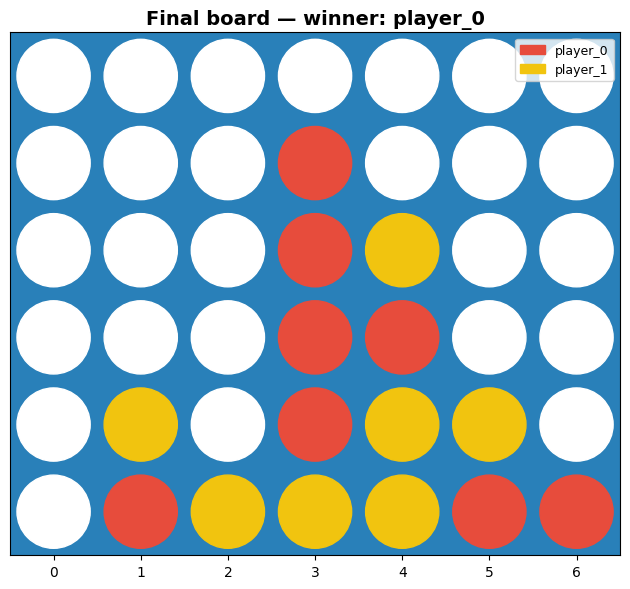

In [4]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap

# ── Board rendering ───────────────────────────────────────────────────────────

TOKEN_COLORS = {0: "white", 1: "#e74c3c", 2: "#f1c40f"}  # empty / p0 red / p1 yellow


def render_board(board: np.ndarray, title: str = "Connect Four"):
    fig, ax = plt.subplots(figsize=(7, 6))
    ax.set_facecolor("#2980b9")
    ax.set_xlim(-0.5, COLS - 0.5)
    ax.set_ylim(-0.5, ROWS - 0.5)
    ax.set_aspect("equal")
    ax.set_xticks(range(COLS))
    ax.set_xticklabels([str(c) for c in range(COLS)])
    ax.set_yticks([])
    ax.set_title(title, fontsize=14, fontweight="bold")

    for r in range(ROWS):
        for c in range(COLS):
            token = board[r, c]
            color = TOKEN_COLORS[token]
            circle = plt.Circle((c, ROWS - 1 - r), 0.42, color=color, zorder=2)
            ax.add_patch(circle)

    legend = [
        mpatches.Patch(color=TOKEN_COLORS[1], label="player_0"),
        mpatches.Patch(color=TOKEN_COLORS[2], label="player_1"),
    ]
    ax.legend(handles=legend, loc="upper right", fontsize=9)
    plt.tight_layout()
    plt.show()


# ── Instrumented game — records board snapshots ───────────────────────────────


def play_and_record(n_simulations: int = 300, c: float = math.sqrt(2)):
    """Play a game and return (outcome, list_of_board_snapshots)."""
    env = connect_four_v3.env(render_mode=None)
    env.reset(seed=42)

    agents = {
        "player_0": MCTSAgent(n_simulations=n_simulations, c=c),
        "player_1": MCTSAgent(n_simulations=n_simulations, c=c),
    }
    player_idx = {"player_0": 0, "player_1": 1}

    snapshots = []
    move_log = []
    outcome = "draw"

    for agent_name in env.agent_iter():
        observation, reward, termination, truncation, info = env.last()

        if termination or truncation:
            if reward == 1:
                outcome = agent_name
            elif reward == -1:
                other = "player_1" if agent_name == "player_0" else "player_0"
                outcome = other
            env.step(None)
            continue

        state = ConnectFourState.from_pettingzoo_obs(
            observation, player_idx[agent_name]
        )
        action = agents[agent_name].select_action(state)
        move_log.append((agent_name, action))

        # record board *after* the move
        next_state = state.apply_action(action)
        snapshots.append((next_state.board.copy(), agent_name, action))

        env.step(action)

    env.close()
    return outcome, snapshots, move_log


print("Rendering helper defined ✓")
print("Running recorded game (200 sims/move) …")
outcome, snapshots, move_log = play_and_record(n_simulations=200)
print(f"Game outcome: {outcome}")
print("Move log:", [(a, col) for a, col in move_log])

# Show final board
if snapshots:
    final_board, last_player, last_col = snapshots[-1]
    render_board(final_board, title=f"Final board — winner: {outcome}")

Evaluating MCTS(300) vs random over 20 games …
  game  1/20: player_0
  game  2/20: player_0
  game  3/20: player_0
  game  4/20: player_0
  game  5/20: player_0
  game  6/20: player_0
  game  7/20: player_0
  game  8/20: player_0
  game  9/20: player_0
  game 10/20: player_0
  game 11/20: player_0
  game 12/20: player_0
  game 13/20: player_0
  game 14/20: player_0
  game 15/20: player_0
  game 16/20: player_0
  game 17/20: player_0
  game 18/20: player_0
  game 19/20: player_0
  game 20/20: player_0

MCTS agent results: {'win': 20}


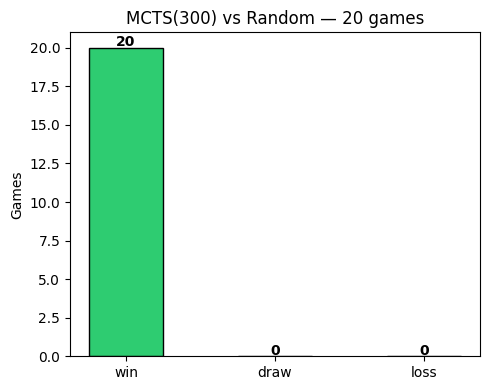

In [5]:
# ── Win-rate evaluation: MCTS(n) vs random agent ─────────────────────────────


def play_mcts_vs_random(n_simulations: int = 300, n_games: int = 20) -> dict:
    """Play MCTS (player_0) against a random agent (player_1).

    Returns win/loss/draw counts for the MCTS agent.
    """
    from collections import Counter

    counter = Counter()
    for game_idx in range(n_games):
        env = connect_four_v3.env(render_mode=None)
        env.reset()

        mcts = MCTSAgent(n_simulations=n_simulations)
        outcome = "draw"

        for agent_name in env.agent_iter():
            observation, reward, termination, truncation, _ = env.last()

            if termination or truncation:
                if reward == 1:
                    outcome = agent_name
                elif reward == -1:
                    outcome = "player_1" if agent_name == "player_0" else "player_0"
                env.step(None)
                continue

            mask = observation["action_mask"]
            if agent_name == "player_0":
                state = ConnectFourState.from_pettingzoo_obs(observation, 0)
                action = mcts.select_action(state)
            else:
                # Random legal move
                action = random.choice([i for i, m in enumerate(mask) if m])

            env.step(action)

        env.close()
        if outcome == "player_0":
            counter["win"] += 1
        elif outcome == "player_1":
            counter["loss"] += 1
        else:
            counter["draw"] += 1

        print(f"  game {game_idx + 1:>2}/{n_games}: {outcome}")

    return dict(counter)


print("Evaluating MCTS(300) vs random over 20 games …")
stats = play_mcts_vs_random(n_simulations=300, n_games=20)
print(f"\nMCTS agent results: {stats}")

# Bar chart
fig, ax = plt.subplots(figsize=(5, 4))
labels = ["win", "draw", "loss"]
values = [stats.get(k, 0) for k in labels]
colors = ["#2ecc71", "#95a5a6", "#e74c3c"]
ax.bar(labels, values, color=colors, edgecolor="black", width=0.5)
ax.set_ylabel("Games")
ax.set_title(f"MCTS({300}) vs Random — {sum(values)} games")
for i, v in enumerate(values):
    ax.text(i, v + 0.1, str(v), ha="center", fontweight="bold")
plt.tight_layout()
plt.show()